# Causal Discovery and Causal Feature Selection for Robust Prediction

This tutorial walks through the key ideas and algorithms at the intersection of causal inference and robust machine learning.
The tutorial is structured as follows:

1. **Pairwise causal discovery** — can we tell which variable causes which, from observational data alone?
2. **Multivariate causal discovery** — recovering the full causal graph over many variables
3. **Multivariate causal feature selection** — finding the Markov Blanket of a target variable
4. **CFS for robust prediction** — why causal parents are more stable predictors than correlated features
5. **Invariant Causal Predictors** — a principled method to find invariant features across environments

In [26]:
import os
if not os.path.exists('zh03-causal-discovery-robust-predictions'):
    !git clone https://github.com/WinterSchool2026/zh03-causal-discovery-robust-predictions.git
import sys
sys.path.insert(0, 'zh03-causal-discovery-robust-predictions')

In [27]:
pip install causal-learn

Note: you may need to restart the kernel to use updated packages.


In [28]:
# Standard library
import time

# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Custom modules / Causal discovery
from src.causal_feature_selection import (
    hiton_mb, iamb, mmpc, mb_ges, resit_mb, hiton_pc
)

from src.linGAM import *

# Data generation
from src.generate_scm import *

import random

random.seed(6)
np.random.seed(6)

---
## Section 4 — CFS for Robust Prediction

### 4.1 The distribution shift problem

Standard machine learning optimizes for expected loss on training data. In deployment, the distribution may shift. We focus here on **intervention shifts**: an external manipulation forces a variable to a particular value, breaking its natural causal mechanism.

Formally, an intervention $do(X_i = x)$ replaces the structural equation for $X_i$, which propagates to all downstream variables. We want to understand which predictors of Y remain reliable after such interventions?

### 4.2 Why standard predictors degrade

Consider a graph where $A → Y ← B → C$. Under the training distribution, $C$ correlates with $Y$ via $B$, and a full regression on $(A, B, C)$ will assign weight to $C$. But if we intervene on $B$, the $B → C$ edge is broken. $C$ no longer tracks Y the way it did in training. The predictor breaks.

The structural equation for Y is:

$$Y = f(\text{PA}(Y), \varepsilon_Y)$$

This equation is **invariant** to interventions on any variable other than Y itself. Parents of Y are therefore the most robust feature set.

However this set is sometimes **over conservative**. Especially children in causal graph might be very predictive of their parents and if we don't expect the relationship between the target variable and its children to break at test time, then we should use the precious information they contain about the target. A very useful set of variable for this is the Markov Blanket (MB) as the rest of the variables are independent of the target conditioned on the markov blanket. It is thus the smallest set of variables that has optimal predicitve power under no distribution shift. By having a restricted number of variables it is also robust to a large range of interventions (outside of the MB).

### 4.3 Setup: SCM with `generate_dag`

We use `generate_dag` and `fit_from_adjacency` to build a controlled SCM, then track which nodes are parents, children, spouses, and unrelated ("others") with respect to Y.


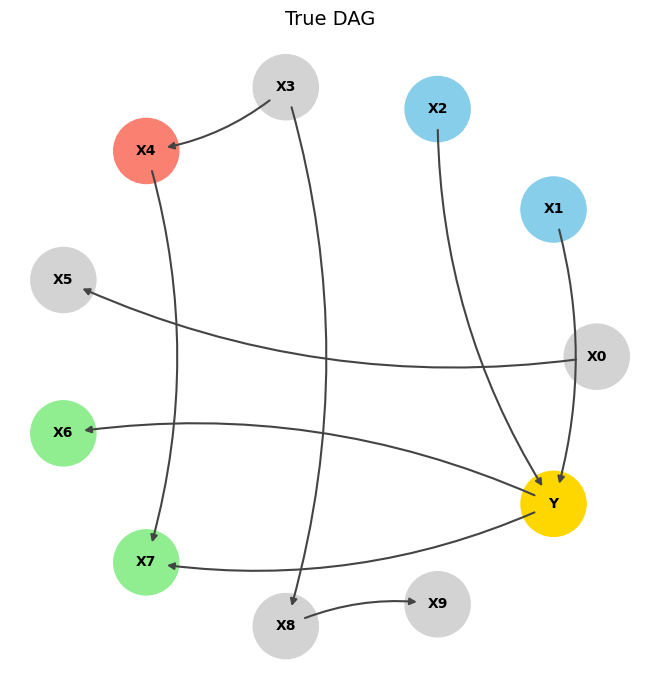

Parents of Y:  [np.int64(1), np.int64(2)]
Children of Y: [np.int64(6), np.int64(7)]
Spouses of Y:  [np.int64(4)]
Others:        [np.int64(0), np.int64(3), np.int64(5), np.int64(8), np.int64(9)]


In [29]:
# Build SCM from an explicit random DAG
d = 10
scm = SCMGenerator(d=d)
A = generate_dag(num_vars=d+1, n_parents=2, n_children=2, n_spouses=1, sparsity=0.15)
scm.fit_from_adjacency(A, Y_idx=d, noise_type='uniform', is_linear=True)

col_names = np.hstack((np.array([f'X{i}' for i in range(scm.n_nodes-1)]), np.array(['Y'])))
plot_graphs_from_adj([scm.A], [d], [col_names], ['True DAG'])

print("Parents of Y: ", sorted(scm.parents_idx))
print("Children of Y:", sorted(scm.children_idx))
print("Spouses of Y: ", sorted(scm.spouses_idx))
print("Others:       ", sorted(scm.others_idx))


In [30]:
# Sample observational data and run CFS algorithms
data = scm.sample(n_samples=10000)
data.head()


,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,Y
0,-0.510818,0.996591,-0.406122,-0.754984,3.561884,-2.316705,15.485066,-38.412405,-4.493843,23.238665,3.873535
1,-0.146848,-0.653910,0.355915,0.657109,-3.047366,-0.873403,-8.278016,24.888142,3.632488,-18.743520,-1.952515
2,0.273767,-0.672304,0.204737,-0.092970,0.136966,1.427408,-11.490474,15.186049,-0.484043,2.323841,-2.875856
3,-0.755224,-0.054802,0.910816,-0.507212,2.762593,-4.088755,13.633385,-31.858404,-2.796511,14.580519,3.411793
4,0.907148,0.770423,-0.988967,-0.354125,1.585876,4.480739,-0.608778,-6.939701,-1.986169,10.182755,-0.060331


In [31]:
# HITON-MB
start = time.time()
mb_hiton = hiton_mb(data, 'Y', alpha=0.05, ci_method='partial')
print(f"HITON-MB  : {time.time()-start:.2f}s  ->  {sorted(mb_hiton)}")

HITON-MB  : 0.32s  ->  ['X4', 'X6', 'X7']


In [32]:
# MB-GES
start = time.time()
mb_ges_result = mb_ges(data, 'Y')
print(f"MB-GES    : {time.time()-start:.2f}s  ->  {sorted(mb_ges_result)}")

MB-GES    : 0.21s  ->  ['X4', 'X6', 'X7']


In [33]:
# IAMB
start = time.time()
mb_iamb = iamb(data, 'Y', alpha=0.05, ci_method='partial')
print(f"IAMB      : {time.time()-start:.2f}s  ->  {sorted(mb_iamb)}")

IAMB      : 0.51s  ->  ['X1', 'X2', 'X4', 'X6', 'X7']


In [34]:
true_mb = set(scm.parents_idx) | set(scm.children_idx) | set(scm.spouses_idx)
print(f"\nTrue MB:    {sorted(true_mb)}")


True MB:    [np.int64(1), np.int64(2), np.int64(4), np.int64(6), np.int64(7)]


### IAMB vs. HITON Summary

#### IAMB (Incremental Association)
- **Strategy:** Global-to-Local. Attempts to find the entire Markov Blanket (MB) at once.
- **Process:** 1. **Growing:** Greedily adds variables with high association to the target.
    2. **Shrinking:** Prunes variables that become independent when others are added.
- **Best For:** Large sample sizes ($n$) where the blanket is relatively small.

#### HITON (Iterative Local)
- **Strategy:** Local-to-Global. Focuses on the immediate neighborhood first.
- **Process:**
    1. **HITON-PC:** Iteratively identifies Parents and Children (PC).
    2. **Spouse Search:** Specifically identifies "spouses" to complete the MB.
- **Best For:** High-dimensional data ($n \ll p$) like genomics; more sample-efficient.

### 4.4 Robustness under intervention: MB vs full predictor

We now compare two predictors:
- **Full predictor**: trained on all features
- **MB predictor**: trained on the MB-GES estimated feature set

We evaluate both as we sweep the intervention value on each group of nodes (parents, children, spouses, others). This produces R² curves as a function of intervention strength.

The design reveals something important: different groups of nodes have different effects on the predictor when intervened on.


In [35]:
# Fit predictors on observational data
predictors_full = data.drop(columns='Y').values
predictors_ges = data[mb_ges_result].values


lr_full = LinearRegression().fit(predictors_full, data['Y'].values)
lr_ges  = LinearRegression().fit(predictors_ges, data['Y'].values)


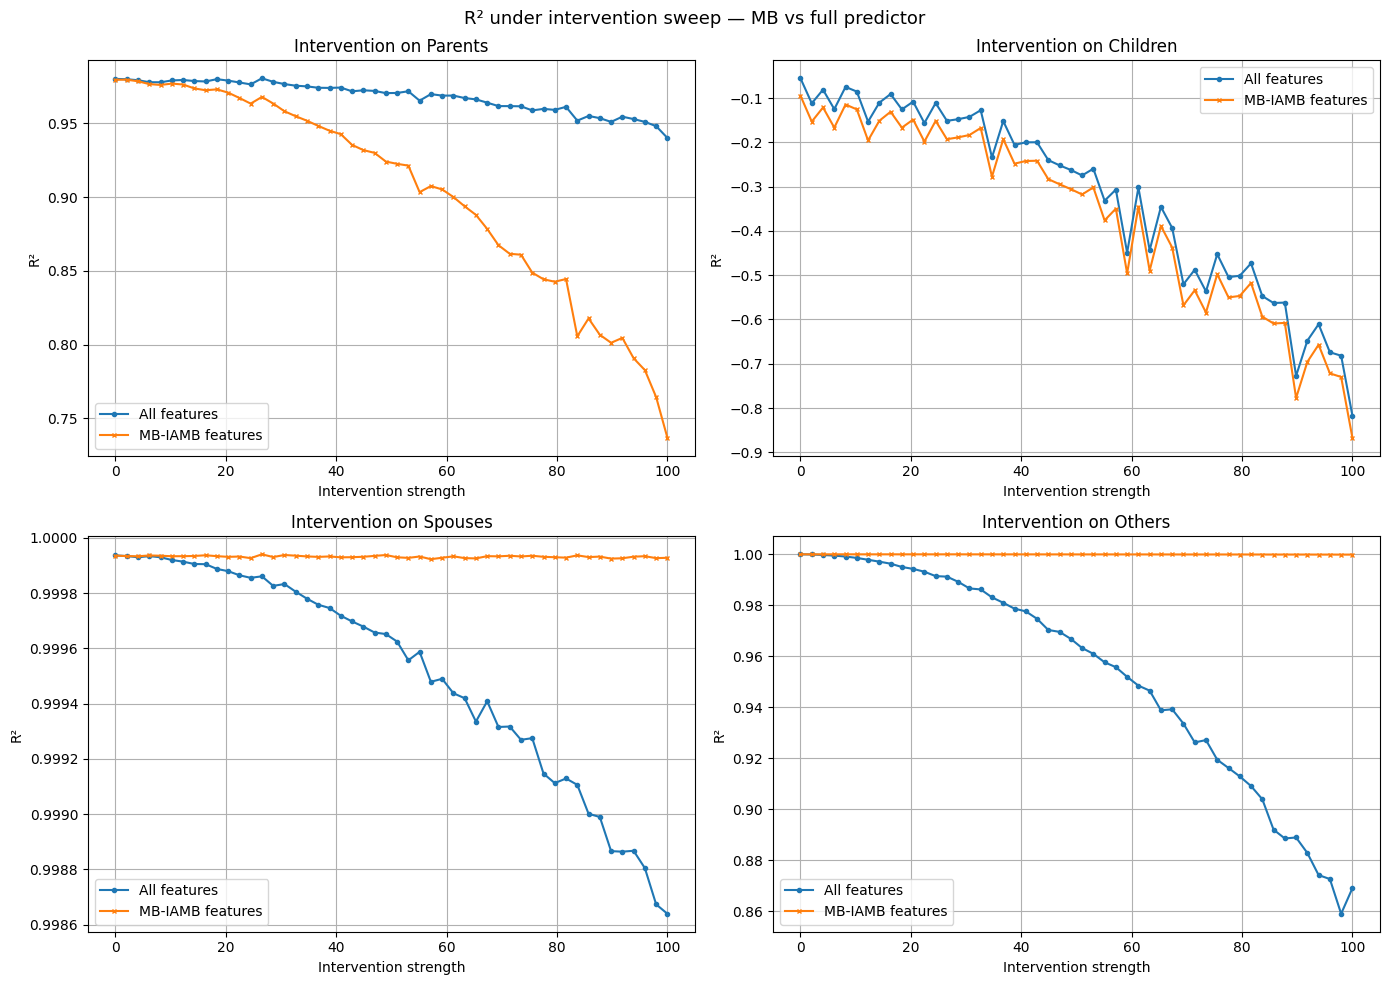

In [36]:
# Sweep intervention values across node groups
intervention_values = np.linspace(0, 100, 50)

intervention_groups = {
    'Parents':  scm.parents_idx,
    'Children': scm.children_idx,
    'Spouses':  scm.spouses_idx,
    'Others':   scm.others_idx
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (group_name, indices) in enumerate(intervention_groups.items()):
    r2_full, r2_ges = [], []
    indices_list = list(indices)

    for val in intervention_values:
        scm_int = scm.intervention(indices=indices_list, values=[val]*len(indices_list))
        data_int = scm_int.sample(n_samples=1000)

        r2_full.append(lr_full.score(data_int.drop(columns='Y').values, data_int['Y'].values))
        r2_ges.append(lr_ges.score(data_int[mb_ges_result].values, data_int['Y'].values))

    axes[i].plot(intervention_values, r2_full, label='All features', marker='o', markersize=3)
    axes[i].plot(intervention_values, r2_ges,  label='MB-IAMB features', marker='x', markersize=3)
    axes[i].set_title(f'Intervention on {group_name}')
    axes[i].set_xlabel('Intervention strength')
    axes[i].set_ylabel('R²')
    axes[i].grid(True)
    axes[i].legend()

plt.suptitle('R² under intervention sweep — MB vs full predictor', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 4.6 — LinGAM


In [37]:
causal_order, B_lingam, parents_lingam = direct_lingam(data, 'Y', threshold=0.10)


In [38]:
print('=' * 55)
print('DirectLiNGAM results')
print('=' * 55)
print()
print(f'LinGAM parents of Y  : {sorted(parents_lingam)}')
print(f'True   parents of Y  : {sorted([f"X{i}" for i in scm.parents_idx])}')

DirectLiNGAM results

LinGAM parents of Y  : ['X1', 'X2']
True   parents of Y  : ['X1', 'X2']


---
## Section 4.7 — Robustness of the LinGAM-parents predictor

We now train one predictor per feature set and compare their R² curves under the same intervention sweep as before.


In [39]:
# Fit one predictor per feature set on the original n=1 000 sample
lingam_parent_cols = parents_lingam

lr_full   = LinearRegression().fit(data.drop(columns='Y').values, data['Y'].values)
lr_ges    = LinearRegression().fit(data[mb_ges_result].values,    data['Y'].values)
lr_lingam = LinearRegression().fit(data[lingam_parent_cols].values, data['Y'].values)

In [40]:
print('Feature sets')
print(f'  All features   : {sorted(data.drop(columns="Y").columns.tolist())}')
print(f'  MB-GES         : {sorted(mb_ges_result)}')
print(f'  LinGAM-parents : {sorted(lingam_parent_cols)}')

# Observational R² (no intervention)
print('\nObservational R² (training distribution)')
print(f'  All features   : {lr_full.score(data.drop(columns="Y").values, data["Y"].values):.3f}')
print(f'  MB-GES         : {lr_ges.score(data[mb_ges_result].values, data["Y"].values):.3f}')
print(f'  LinGAM-parents : {lr_lingam.score(data[lingam_parent_cols].values, data["Y"].values):.3f}')


Feature sets
  All features   : ['X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9']
  MB-GES         : ['X4', 'X6', 'X7']
  LinGAM-parents : ['X1', 'X2']

Observational R² (training distribution)
  All features   : 1.000
  MB-GES         : 1.000
  LinGAM-parents : 0.997


### Interventions


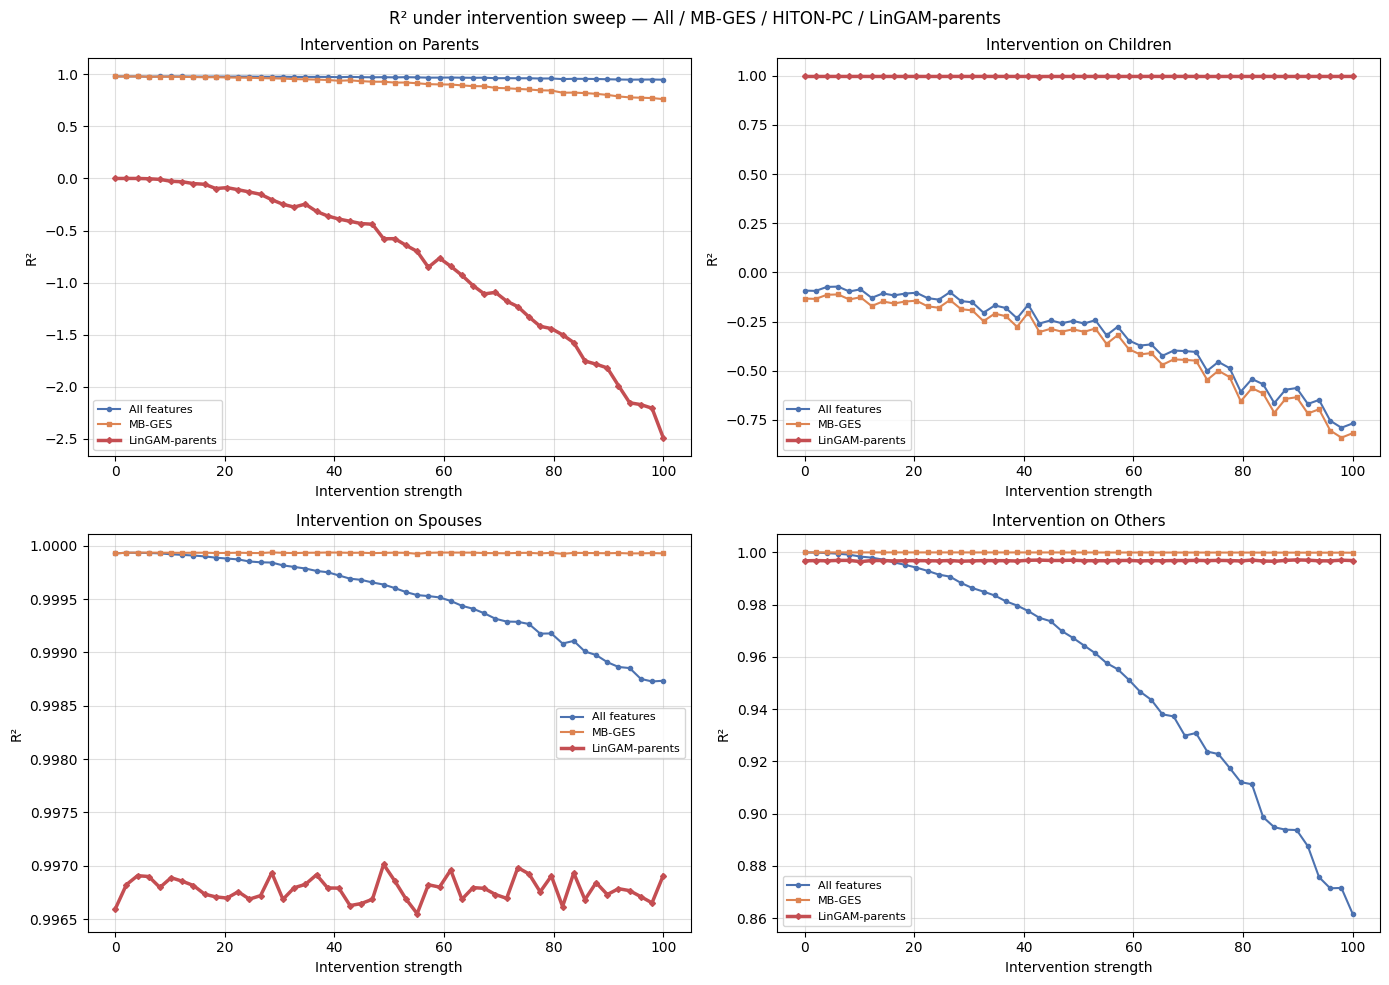

In [41]:
intervention_values = np.linspace(0, 100, 50)

predictor_styles = {
    'All features':   (lr_full,   lambda d: d.drop(columns='Y').values, '#4C72B0', 'o', 1.5),
    'MB-GES':         (lr_ges,    lambda d: d[mb_ges_result].values,     '#DD8452', 's', 1.5),
    'LinGAM-parents': (lr_lingam, lambda d: d[lingam_parent_cols].values,'#C44E52', 'D', 2.5),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax_i, (group_name, indices) in enumerate(intervention_groups.items()):
    idx_list = list(indices)
    r2_scores = {label: [] for label in predictor_styles}

    for val in intervention_values:
        scm_int = scm.intervention(indices=idx_list, values=[val] * len(idx_list))
        d_int   = scm_int.sample(n_samples=2000)
        for label, (model, get_X, *_) in predictor_styles.items():
            r2_scores[label].append(model.score(get_X(d_int), d_int['Y'].values))

    ax = axes[ax_i]
    for label, (_, _, color, marker, lw) in predictor_styles.items():
        ax.plot(intervention_values, r2_scores[label],
                label=label, color=color, marker=marker,
                markersize=3, linewidth=lw,
                zorder=3 if label == 'LinGAM-parents' else 2)
    ax.set_title(f'Intervention on {group_name}', fontsize=11)
    ax.set_xlabel('Intervention strength')
    ax.set_ylabel('R²')
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=8)

plt.suptitle('R² under intervention sweep — All / MB-GES / HITON-PC / LinGAM-parents',
             fontsize=12)
plt.tight_layout()
plt.show()
